# 03 — Division, Pareto & Cost Diagnostics
## Nassau Candy Distributor — Product Line Profitability & Margin Performance Analysis

Aggregates performance by Division, quantifies how concentrated revenue/profit are across products
(Pareto analysis), and flags cost/margin diagnostics for further review.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/cleaned_transactions.csv', parse_dates=['Order Date'])
product = pd.read_csv('../data/product_profitability.csv')
print(f"Transactions: {df.shape[0]:,} | Products: {product.shape[0]}")

Transactions: 9,881 | Products: 15


## 1. Division-Level Analysis

In [2]:
division = df.groupby('Division').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Cost=('Cost', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum'),
    Total_Units=('Units', 'sum'),
    Transactions=('Row ID', 'count'),
).reset_index()

division['Avg_Gross_Margin_Pct'] = division['Total_Gross_Profit'] / division['Total_Sales'] * 100
total_sales = division['Total_Sales'].sum()
total_profit = division['Total_Gross_Profit'].sum()
division['Revenue_Contribution_Pct'] = division['Total_Sales'] / total_sales * 100
division['Profit_Contribution_Pct'] = division['Total_Gross_Profit'] / total_profit * 100
division['Revenue_vs_Profit_Gap_pp'] = division['Profit_Contribution_Pct'] - division['Revenue_Contribution_Pct']

division = division.sort_values('Total_Sales', ascending=False).reset_index(drop=True)
division.round(2)

,Division,Total_Sales,Total_Cost,Total_Gross_Profit,Total_Units,Transactions,Avg_Gross_Margin_Pct,Revenue_Contribution_Pct,Profit_Contribution_Pct,Revenue_vs_Profit_Gap_pp
0,Chocolate,128193.39,41735.16,86458.23,36288,9531,67.44,92.70,94.93,2.23
1,Other,9663.25,5329.80,4333.45,1242,310,44.84,6.99,4.76,-2.23
2,Sugar,427.48,142.75,284.73,137,40,66.61,0.31,0.31,0.00


**Interpretation:** `Revenue_vs_Profit_Gap_pp` is the division's Profit Contribution % minus its
Revenue Contribution % (in percentage points). A positive value means the division punches above its
revenue weight in profit terms (efficient margin); a negative value means it contributes less profit than
its revenue share would suggest.

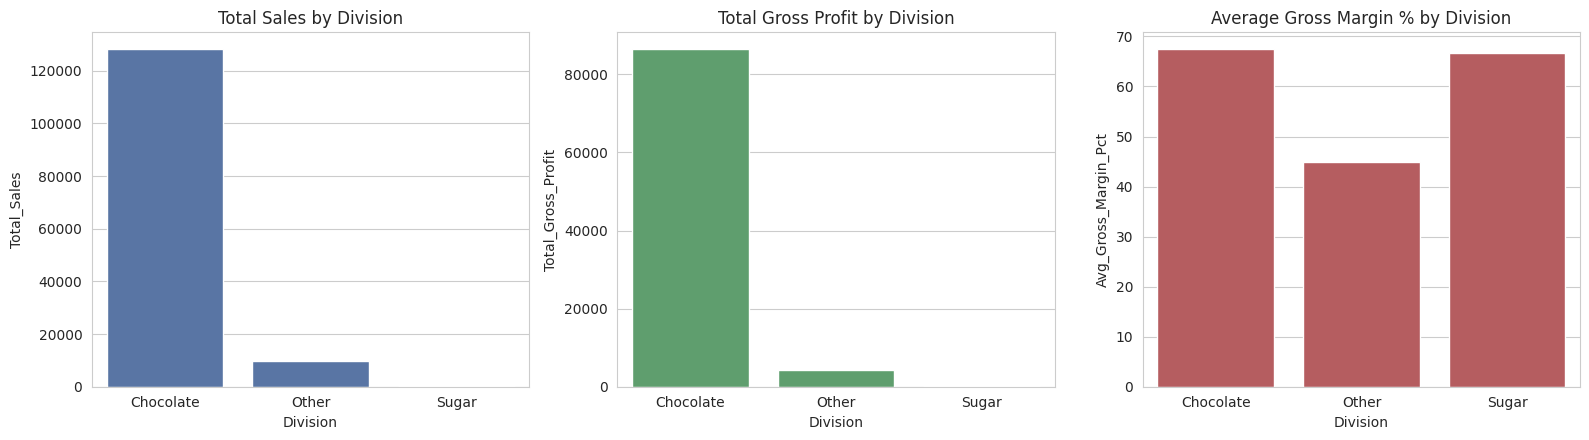

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(x='Division', y='Total_Sales', data=division, ax=axes[0], color='#4C72B0')
axes[0].set_title('Total Sales by Division')
sns.barplot(x='Division', y='Total_Gross_Profit', data=division, ax=axes[1], color='#55A868')
axes[1].set_title('Total Gross Profit by Division')
sns.barplot(x='Division', y='Avg_Gross_Margin_Pct', data=division, ax=axes[2], color='#C44E52')
axes[2].set_title('Average Gross Margin % by Division')
plt.tight_layout()
plt.savefig('../images/division_comparison.png', dpi=120)
plt.show()

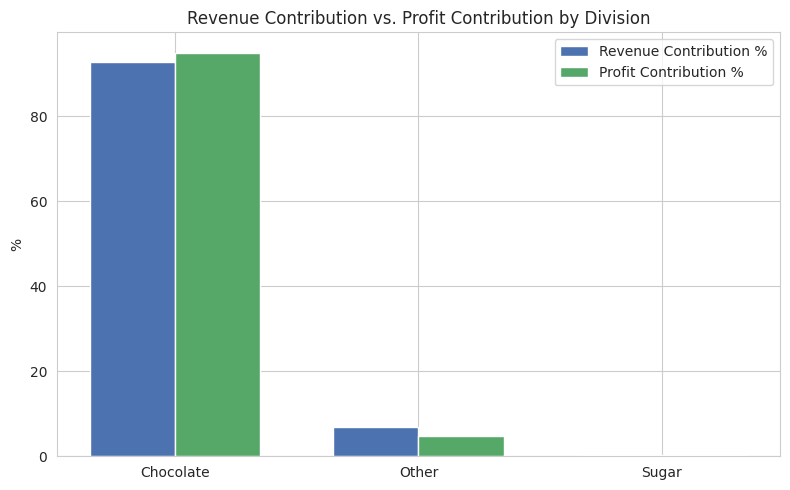

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(division))
width = 0.35
ax.bar(x - width/2, division['Revenue_Contribution_Pct'], width, label='Revenue Contribution %', color='#4C72B0')
ax.bar(x + width/2, division['Profit_Contribution_Pct'], width, label='Profit Contribution %', color='#55A868')
ax.set_xticks(x)
ax.set_xticklabels(division['Division'])
ax.set_ylabel('%')
ax.set_title('Revenue Contribution vs. Profit Contribution by Division')
ax.legend()
plt.tight_layout()
plt.savefig('../images/division_revenue_vs_profit.png', dpi=120)
plt.show()

## 2. Pareto Analysis — Revenue

In [5]:
pareto_rev = product.sort_values('Sales', ascending=False).reset_index(drop=True).copy()
pareto_rev['Cumulative_Sales'] = pareto_rev['Sales'].cumsum()
pareto_rev['Cumulative_Sales_Pct'] = pareto_rev['Cumulative_Sales'] / pareto_rev['Sales'].sum() * 100
pareto_rev['Product_Rank'] = np.arange(1, len(pareto_rev) + 1)
pareto_rev['Product_Rank_Pct'] = pareto_rev['Product_Rank'] / len(pareto_rev) * 100

n_products_for_80_rev = (pareto_rev['Cumulative_Sales_Pct'] < 80).sum() + 1
pct_products_for_80_rev = n_products_for_80_rev / len(pareto_rev) * 100

print(f"{n_products_for_80_rev} of {len(pareto_rev)} products ({pct_products_for_80_rev:.1f}%) generate the first 80% of total revenue.")
pareto_rev[['Product Name', 'Sales', 'Cumulative_Sales_Pct']].round(2)

5 of 15 products (33.3%) generate the first 80% of total revenue.


,Product Name,Sales,Cumulative_Sales_Pct
0,Wonka Bar - Triple Dazzle Caramel,27648.75,19.99
1,Wonka Bar -Scrumdiddlyumptious,27028.80,39.54
2,Wonka Bar - Milk Chocolate,26256.75,58.53
3,Wonka Bar - Fudge Mallows,24361.20,76.14
4,Wonka Bar - Nutty Crunch Surprise,22897.89,92.70
5,Lickable Wallpaper,7860.00,98.39
6,Kazookles,1205.75,99.26
7,Wonka Gum,597.50,99.69
8,Everlasting Gobstopper,130.00,99.78
9,Fizzy Lifting Drinks,78.75,99.84


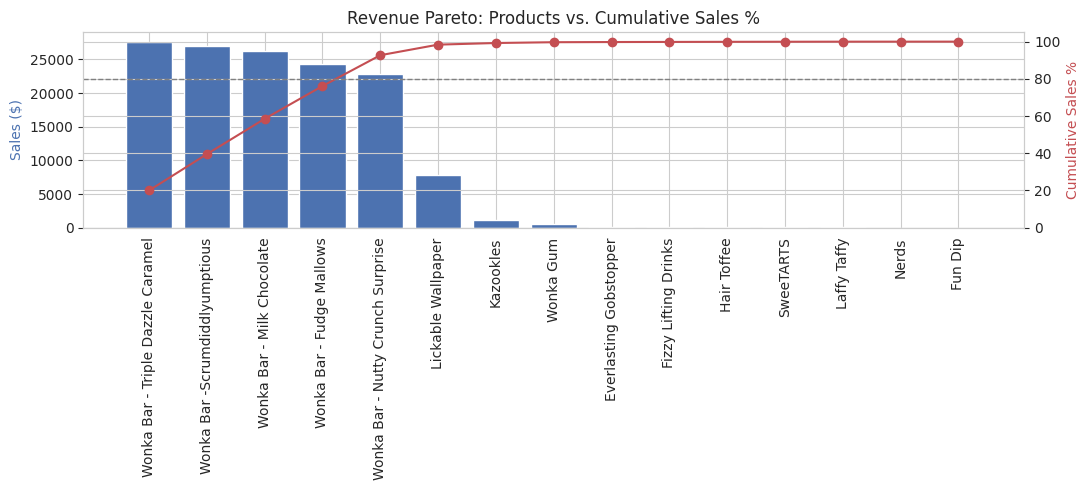

In [6]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(pareto_rev['Product Name'], pareto_rev['Sales'], color='#4C72B0')
ax1.set_ylabel('Sales ($)', color='#4C72B0')
ax1.tick_params(axis='x', rotation=90)
ax2 = ax1.twinx()
ax2.plot(pareto_rev['Product Name'], pareto_rev['Cumulative_Sales_Pct'], color='#C44E52', marker='o')
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Sales %', color='#C44E52')
ax2.set_ylim(0, 105)
plt.title('Revenue Pareto: Products vs. Cumulative Sales %')
plt.tight_layout()
plt.savefig('../images/pareto_revenue.png', dpi=120)
plt.show()

## 3. Pareto Analysis — Gross Profit

In [7]:
pareto_profit = product.sort_values('Gross_Profit', ascending=False).reset_index(drop=True).copy()
pareto_profit['Cumulative_Profit'] = pareto_profit['Gross_Profit'].cumsum()
pareto_profit['Cumulative_Profit_Pct'] = pareto_profit['Cumulative_Profit'] / pareto_profit['Gross_Profit'].sum() * 100
pareto_profit['Product_Rank'] = np.arange(1, len(pareto_profit) + 1)

n_products_for_80_profit = (pareto_profit['Cumulative_Profit_Pct'] < 80).sum() + 1
pct_products_for_80_profit = n_products_for_80_profit / len(pareto_profit) * 100

print(f"{n_products_for_80_profit} of {len(pareto_profit)} products ({pct_products_for_80_profit:.1f}%) generate the first 80% of total gross profit.")
pareto_profit[['Product Name', 'Gross_Profit', 'Cumulative_Profit_Pct']].round(2)

5 of 15 products (33.3%) generate the first 80% of total gross profit.


,Product Name,Gross_Profit,Cumulative_Profit_Pct
0,Wonka Bar -Scrumdiddlyumptious,18770.00,20.61
1,Wonka Bar - Triple Dazzle Caramel,18063.85,40.44
2,Wonka Bar - Milk Chocolate,17046.69,59.16
3,Wonka Bar - Nutty Crunch Surprise,16336.89,77.10
4,Wonka Bar - Fudge Mallows,16240.80,94.93
5,Lickable Wallpaper,3930.00,99.24
6,Wonka Gum,310.70,99.59
7,Everlasting Gobstopper,104.00,99.70
8,Kazookles,92.75,99.80
9,Hair Toffee,59.50,99.87


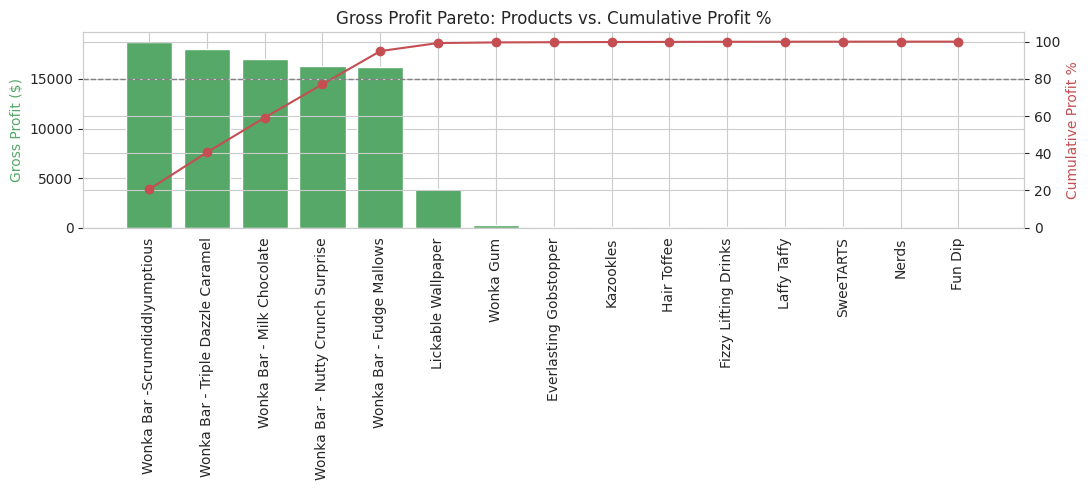

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.bar(pareto_profit['Product Name'], pareto_profit['Gross_Profit'], color='#55A868')
ax1.set_ylabel('Gross Profit ($)', color='#55A868')
ax1.tick_params(axis='x', rotation=90)
ax2 = ax1.twinx()
ax2.plot(pareto_profit['Product Name'], pareto_profit['Cumulative_Profit_Pct'], color='#C44E52', marker='o')
ax2.axhline(80, color='grey', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative Profit %', color='#C44E52')
ax2.set_ylim(0, 105)
plt.title('Gross Profit Pareto: Products vs. Cumulative Profit %')
plt.tight_layout()
plt.savefig('../images/pareto_profit.png', dpi=120)
plt.show()

**Business meaning of concentration:** With only 15 products, a very small number of them (the five
Wonka Bar chocolate SKUs) account for the large majority of both revenue and profit. This indicates Nassau
Candy's financial performance is **heavily dependent on a handful of chocolate products** — a concentration
risk. If demand, cost, or supply for any one of those core SKUs were disrupted, the impact on total company
profit would be disproportionate. This is calculated directly from the data above, not assumed.

## 4. Cost & Margin Diagnostics

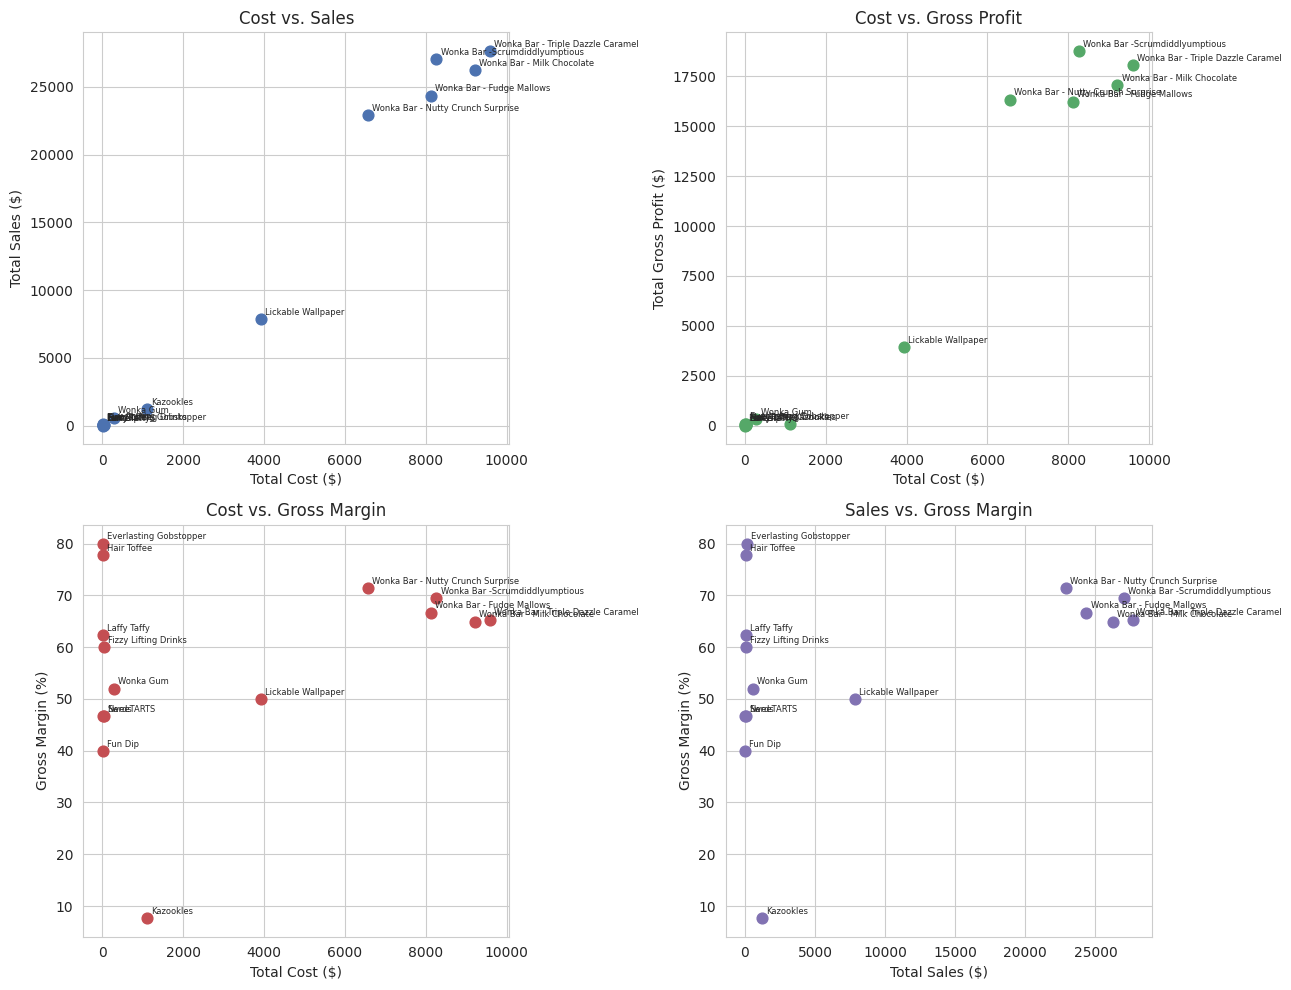

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0,0].scatter(product['Cost'], product['Sales'], s=60, color='#4C72B0')
for _, r in product.iterrows():
    axes[0,0].annotate(r['Product Name'], (r['Cost'], r['Sales']), fontsize=6, xytext=(3,3), textcoords='offset points')
axes[0,0].set_xlabel('Total Cost ($)'); axes[0,0].set_ylabel('Total Sales ($)'); axes[0,0].set_title('Cost vs. Sales')

axes[0,1].scatter(product['Cost'], product['Gross_Profit'], s=60, color='#55A868')
for _, r in product.iterrows():
    axes[0,1].annotate(r['Product Name'], (r['Cost'], r['Gross_Profit']), fontsize=6, xytext=(3,3), textcoords='offset points')
axes[0,1].set_xlabel('Total Cost ($)'); axes[0,1].set_ylabel('Total Gross Profit ($)'); axes[0,1].set_title('Cost vs. Gross Profit')

axes[1,0].scatter(product['Cost'], product['Gross_Margin_Pct'], s=60, color='#C44E52')
for _, r in product.iterrows():
    axes[1,0].annotate(r['Product Name'], (r['Cost'], r['Gross_Margin_Pct']), fontsize=6, xytext=(3,3), textcoords='offset points')
axes[1,0].set_xlabel('Total Cost ($)'); axes[1,0].set_ylabel('Gross Margin (%)'); axes[1,0].set_title('Cost vs. Gross Margin')

axes[1,1].scatter(product['Sales'], product['Gross_Margin_Pct'], s=60, color='#8172B2')
for _, r in product.iterrows():
    axes[1,1].annotate(r['Product Name'], (r['Sales'], r['Gross_Margin_Pct']), fontsize=6, xytext=(3,3), textcoords='offset points')
axes[1,1].set_xlabel('Total Sales ($)'); axes[1,1].set_ylabel('Gross Margin (%)'); axes[1,1].set_title('Sales vs. Gross Margin')

plt.tight_layout()
plt.savefig('../images/cost_margin_diagnostics.png', dpi=120)
plt.show()

## 5. Review Flags (Not Automatic Decisions)

In [10]:
margin_median = product['Gross_Margin_Pct'].median()
sales_median = product['Sales'].median()

flags = product.copy()

flags['Flag_Margin_Risk'] = (flags['Sales'] >= sales_median) & (flags['Gross_Margin_Pct'] < margin_median)
flags['Flag_Low_Margin_Overall'] = flags['Gross_Margin_Pct'] < flags['Gross_Margin_Pct'].quantile(0.25)
flags['Flag_High_Efficiency'] = (flags['Gross_Margin_Pct'] >= flags['Gross_Margin_Pct'].quantile(0.75)) & (flags['Sales'] >= sales_median)

print("Potential repricing / cost-review candidates (bottom quartile margin):")
print(flags.loc[flags['Flag_Low_Margin_Overall'], ['Product Name', 'Division', 'Gross_Margin_Pct']].to_string(index=False))

print()
print("High-sales but comparatively weak-margin products (margin-risk review):")
print(flags.loc[flags['Flag_Margin_Risk'], ['Product Name', 'Division', 'Sales', 'Gross_Margin_Pct']].to_string(index=False))

print()
print("High-profit, high-efficiency products:")
print(flags.loc[flags['Flag_High_Efficiency'], ['Product Name', 'Division', 'Sales', 'Gross_Margin_Pct']].to_string(index=False))

Potential repricing / cost-review candidates (bottom quartile margin):
Product Name Division  Gross_Margin_Pct
   Kazookles    Other              7.69
   SweeTARTS    Sugar             46.67
       Nerds    Sugar             46.67
     Fun Dip    Sugar             40.00

High-sales but comparatively weak-margin products (margin-risk review):
      Product Name Division   Sales  Gross_Margin_Pct
Lickable Wallpaper    Other 7860.00             50.00
         Kazookles    Other 1205.75              7.69
         Wonka Gum    Other  597.50             52.00

High-profit, high-efficiency products:
                     Product Name  Division    Sales  Gross_Margin_Pct
   Wonka Bar -Scrumdiddlyumptious Chocolate 27028.80             69.44
Wonka Bar - Nutty Crunch Surprise Chocolate 22897.89             71.35


**Note:** These are review flags computed from documented, transparent thresholds (quartiles /
medians of the actual data) — they are starting points for a pricing, sourcing, or cost-reduction
conversation, not automatic verdicts that a product should be discontinued.

In [11]:
flags.to_csv('../data/cost_margin_flags.csv', index=False)
print("Saved ../data/cost_margin_flags.csv")

Saved ../data/cost_margin_flags.csv


## 6. Notebook 3 Summary

- **Division performance:** Chocolate leads on both Sales and Gross Profit; its Avg Gross Margin and
  Revenue-vs-Profit gap are computed in Section 1 directly from the data (see table/chart above) rather than
  assumed here.
- **Pareto concentration:** the exact number of products responsible for 80% of revenue and 80% of profit is
  computed and printed in Sections 2–3 above (not fabricated) — both concentration levels point to a small
  set of chocolate SKUs carrying the company's financial performance.
- **Cost/margin diagnostics:** scatter plots and quartile-based review flags in Sections 4–5 highlight which
  products are comparatively cost-heavy/margin-poor vs. efficient, saved to `data/cost_margin_flags.csv` for
  use in the dashboard.
- All findings here are used as inputs to the Streamlit dashboard's Division Performance, Profit
  Concentration, and Cost vs. Margin Diagnostics sections.